# Lead-Time Analysis

This notebook evaluates how early the trained progression models can flag conversion, using truncated visit histories.

**Experimental setup recap** (see `leadtime.py`):
- For every **progressor** (`Prog_ID == 1`), the model is run on progressively longer visit-history truncations — starting at 2 visits, up to the full visit history (which includes the visit where conversion is recorded). Column `0` = prediction using the first 2 visits, column `1` = first 3 visits, etc.
- For every **non-progressor / control** (`Prog_ID == 0`), the same truncation scheme is applied (optionally masking the most recent visits), so any positive prediction is a false alarm since these subjects never actually progress.
- `months_since_baseline` gives the visit months for the *full, untruncated* sequence. Prediction column `i` (truncation length `i+2`) uses visits `[0 : i+2]`, so its "current" visit is index `i+1`, and the corresponding elapsed time is `months_since_baseline[i+1]`.
- For progressors, the final column's truncation includes the actual conversion visit, so `months_since_baseline[-1]` is the true conversion time. Lead time for a given alarm = `conversion_month - alarm_month`.

Below we compute detection/false-alarm rates and lead-time distributions for both cohorts.


In [1]:
import ast
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _parse_list(s):
    """Parse stringified list columns (months_since_baseline, Progression)."""
    if isinstance(s, str):
        return ast.literal_eval(s)
    return s


def _pred_cols(df):
    """Return the truncation-index prediction columns ('0', '1', ...), sorted numerically."""
    cols = [c for c in df.columns if c not in ('ID', 'months_since_baseline', 'Progression')]
    return sorted(cols, key=lambda x: int(x))


def load_leadtime_results(base_dir):
    """Load progressor (lead_time_*) and control (control_*) prediction csvs for a cohort dir."""
    prog_pred = pd.read_csv(os.path.join(base_dir, 'lead_time_predictions.csv'))
    ctrl_pred = pd.read_csv(os.path.join(base_dir, 'control_predictions.csv'))
    for df in (prog_pred, ctrl_pred):
        df['months_since_baseline'] = df['months_since_baseline'].apply(_parse_list)
        df['Progression'] = df['Progression'].apply(_parse_list)
    return prog_pred, ctrl_pred


def analyze_progressors(prog_pred):
    """For each progressor, find the first truncation at which the model raised an alarm (pred==1),
    and compute the resulting lead time relative to the true conversion visit."""
    pred_cols = _pred_cols(prog_pred)
    records = []
    for _, row in prog_pred.iterrows():
        months = row['months_since_baseline']
        conversion_month = months[-1]
        baseline_month = months[0]

        first_alarm_idx = None
        for c in pred_cols:
            val = row[c]
            if pd.notna(val) and val == 1:
                first_alarm_idx = int(c)
                break

        if first_alarm_idx is None:
            status = 'missed'
            lead_time = np.nan
            alarm_month = np.nan
        else:
            alarm_month = months[first_alarm_idx + 1]
            lead_time = conversion_month - alarm_month
            status = 'detected_early' if lead_time > 0 else 'detected_at_conversion'

        records.append({
            'ID': row['ID'],
            'baseline_month': baseline_month,
            'conversion_month': conversion_month,
            'alarm_month': alarm_month,
            'lead_time_months': lead_time,
            'status': status,
        })
    return pd.DataFrame(records)


def analyze_controls(ctrl_pred):
    """For each control (non-progressor), compute whether/how often the model raised a false alarm."""
    pred_cols = _pred_cols(ctrl_pred)
    records = []
    for _, row in ctrl_pred.iterrows():
        vals = [row[c] for c in pred_cols if pd.notna(row[c])]
        n_alarms = int(sum(v == 1 for v in vals))
        records.append({
            'ID': row['ID'],
            'n_visits_predicted': len(vals),
            'n_false_alarms': n_alarms,
            'any_false_alarm': n_alarms > 0,
            'false_alarm_rate': n_alarms / len(vals) if vals else np.nan,
        })
    return pd.DataFrame(records)


def summarize_leadtime(prog_df, ctrl_df, label=""):
    """Print sensitivity/specificity and lead-time stats for one cohort."""
    n_prog = len(prog_df)
    n_detected = int((prog_df['status'] != 'missed').sum())
    n_early = int((prog_df['status'] == 'detected_early').sum())
    n_at_conv = int((prog_df['status'] == 'detected_at_conversion').sum())
    n_missed = int((prog_df['status'] == 'missed').sum())
    sensitivity = n_detected / n_prog if n_prog else np.nan

    n_ctrl = len(ctrl_df)
    n_false_alarm = int(ctrl_df['any_false_alarm'].sum())
    specificity = 1 - n_false_alarm / n_ctrl if n_ctrl else np.nan

    lead_times = prog_df.loc[prog_df['status'] == 'detected_early', 'lead_time_months']

    print(f"===== {label} Lead-Time Analysis =====")
    print(f"Progressors: {n_prog}")
    print(f"  Detected (any point):            {n_detected:3d} ({sensitivity:.1%})")
    print(f"    - Detected early (pre-conversion): {n_early:3d} ({n_early/n_prog:.1%})")
    print(f"    - Detected only at conversion:     {n_at_conv:3d} ({n_at_conv/n_prog:.1%})")
    print(f"  Missed entirely:                  {n_missed:3d} ({n_missed/n_prog:.1%})")
    if len(lead_times):
        print(f"  Lead time (months) among early detections: "
              f"mean={lead_times.mean():.1f}, median={lead_times.median():.1f}, "
              f"min={lead_times.min():.1f}, max={lead_times.max():.1f}")
    print(f"\nControls (non-progressors): {n_ctrl}")
    print(f"  False alarms (>=1 visit): {n_false_alarm:3d} ({n_false_alarm/n_ctrl:.1%})")
    print(f"  Specificity: {specificity:.1%}")

    return {
        'n_prog': n_prog, 'n_detected': n_detected, 'n_early': n_early,
        'n_at_conv': n_at_conv, 'n_missed': n_missed, 'sensitivity': sensitivity,
        'n_ctrl': n_ctrl, 'n_false_alarm': n_false_alarm, 'specificity': specificity,
        'lead_times': lead_times,
    }


def plot_leadtime_summary(prog_df, ctrl_df, label=""):
    """Plot detection outcome breakdown, lead-time distribution, and control false-alarm rate."""
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    status_order = ['detected_early', 'detected_at_conversion', 'missed']
    status_counts = prog_df['status'].value_counts().reindex(status_order, fill_value=0)
    axes[0].bar(['Early', 'At conversion', 'Missed'], status_counts.values,
                color=['#2ca02c', '#ff7f0e', '#d62728'])
    axes[0].set_title(f"{label}: Progressor Detection Outcomes")
    axes[0].set_ylabel("Number of subjects")

    lead_times = prog_df.loc[prog_df['status'] == 'detected_early', 'lead_time_months']
    if len(lead_times):
        axes[1].hist(lead_times, bins=15, color='#1f77b4', edgecolor='white')
    axes[1].set_title(f"{label}: Lead Time Distribution")
    axes[1].set_xlabel("Months before conversion")
    axes[1].set_ylabel("Count")

    fa_counts = ctrl_df['any_false_alarm'].value_counts().reindex([False, True], fill_value=0)
    axes[2].bar(['No alarm', 'False alarm'], fa_counts.values, color=['#2ca02c', '#d62728'])
    axes[2].set_title(f"{label}: Control False Alarms")
    axes[2].set_ylabel("Number of subjects")

    plt.tight_layout()
    plt.show()


## CN_MCI results

1. Analyze the false positive / true positive rates of predictions, how many conversions were predicted early, how many predictions were false alarms. This is a clinical diagnostic trial on a small subset. 
2. Produce a chart and some visualizations. 

In [2]:
cn_prog_pred, cn_ctrl_pred = load_leadtime_results('CN')

cn_prog_df = analyze_progressors(cn_prog_pred)
cn_ctrl_df = analyze_controls(cn_ctrl_pred)

cn_stats = summarize_leadtime(cn_prog_df, cn_ctrl_df, label='CN_MCI')


===== CN_MCI Lead-Time Analysis =====
Progressors: 119
  Detected (any point):            108 (90.8%)
    - Detected early (pre-conversion):  76 (63.9%)
    - Detected only at conversion:      32 (26.9%)
  Missed entirely:                   11 (9.2%)
  Lead time (months) among early detections: mean=44.4, median=36.5, min=9.4, max=130.7

Controls (non-progressors): 526
  False alarms (>=1 visit):  84 (16.0%)
  Specificity: 84.0%


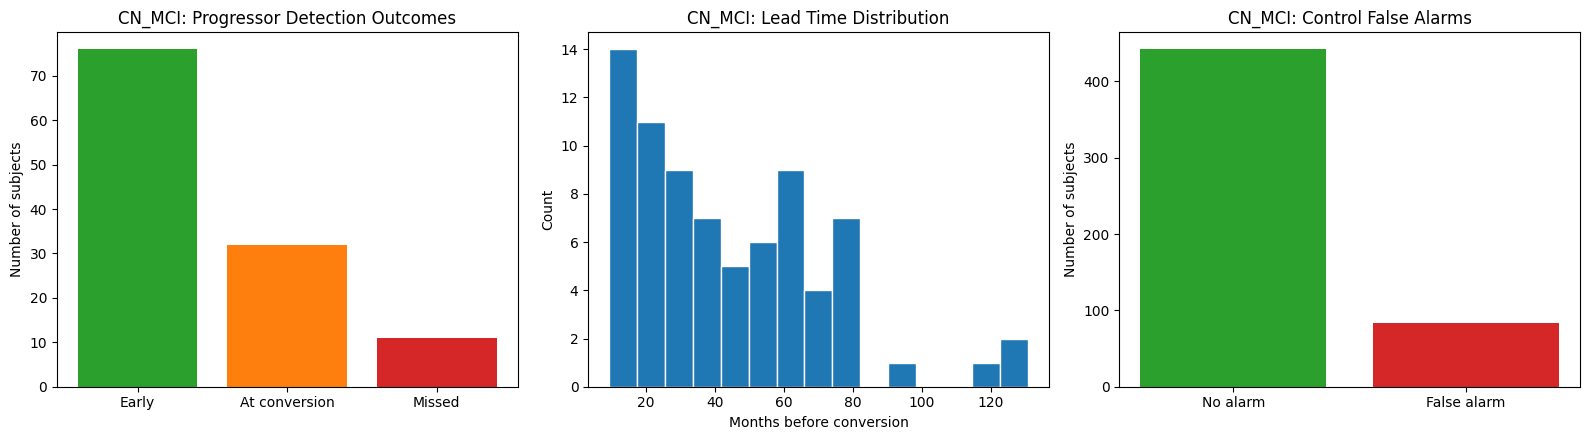

,ID,baseline_month,conversion_month,alarm_month,lead_time_months,status
115,NACC615860,0.0,142.74,12.02,130.72,detected_early
93,NACC136846,0.0,136.30,11.99,124.31,detected_early
104,NACC576836,0.0,138.24,16.29,121.95,detected_early
113,NACC839325,0.0,110.09,12.84,97.25,detected_early
102,NACC223876,0.0,107.65,25.99,81.66,detected_early
100,NACC219367,0.0,108.44,28.29,80.15,detected_early
75,NACC819869,0.0,94.71,15.47,79.24,detected_early
97,NACC326959,0.0,90.14,11.27,78.87,detected_early
109,NACC614575,0.0,100.99,24.51,76.48,detected_early
71,NACC666849,0.0,87.78,11.33,76.45,detected_early


In [3]:
plot_leadtime_summary(cn_prog_df, cn_ctrl_df, label='CN_MCI')
cn_prog_df.sort_values('lead_time_months', ascending=False).head(10)


## MCI_AD results

In [4]:
mci_prog_pred, mci_ctrl_pred = load_leadtime_results('MCI_AD')

mci_prog_df = analyze_progressors(mci_prog_pred)
mci_ctrl_df = analyze_controls(mci_ctrl_pred)

mci_stats = summarize_leadtime(mci_prog_df, mci_ctrl_df, label='MCI_AD')


===== MCI_AD Lead-Time Analysis =====
Progressors: 79
  Detected (any point):             62 (78.5%)
    - Detected early (pre-conversion):  49 (62.0%)
    - Detected only at conversion:      13 (16.5%)
  Missed entirely:                   17 (21.5%)
  Lead time (months) among early detections: mean=37.1, median=33.3, min=7.9, max=100.3

Controls (non-progressors): 78
  False alarms (>=1 visit):   8 (10.3%)
  Specificity: 89.7%


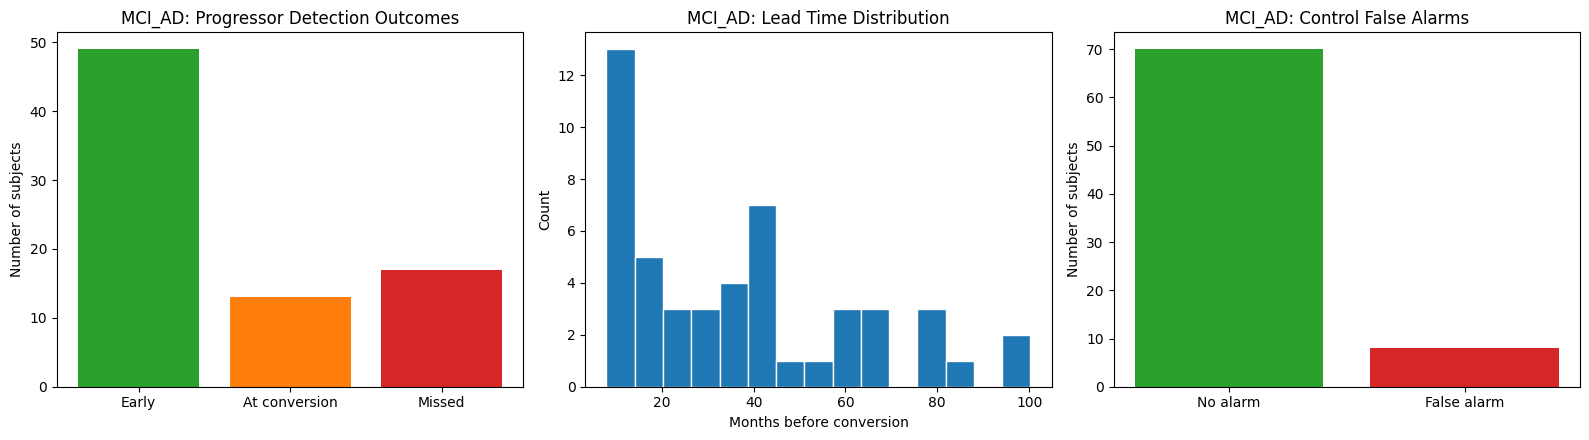

,ID,baseline_month,conversion_month,alarm_month,lead_time_months,status
78,NACC889008,0.0,126.08,25.79,100.29,detected_early
77,NACC829412,0.0,108.57,12.16,96.41,detected_early
73,NACC510442,0.0,108.84,22.60,86.24,detected_early
63,NACC413660,0.0,90.11,11.27,78.84,detected_early
69,NACC055816,0.0,114.26,35.87,78.39,detected_early
70,NACC867814,0.0,90.34,14.65,75.69,detected_early
74,NACC097876,0.0,97.50,28.78,68.72,detected_early
71,NACC267197,0.0,84.49,16.79,67.70,detected_early
75,NACC527308,0.0,97.27,30.81,66.46,detected_early
59,NACC333104,0.0,82.13,21.62,60.51,detected_early


In [5]:
plot_leadtime_summary(mci_prog_df, mci_ctrl_df, label='MCI_AD')
mci_prog_df.sort_values('lead_time_months', ascending=False).head(10)


## Cohort Comparison


In [6]:
comparison = pd.DataFrame({
    'CN_MCI': {
        'n_progressors': cn_stats['n_prog'],
        'sensitivity': cn_stats['sensitivity'],
        'pct_detected_early': cn_stats['n_early'] / cn_stats['n_prog'],
        'pct_detected_at_conversion': cn_stats['n_at_conv'] / cn_stats['n_prog'],
        'pct_missed': cn_stats['n_missed'] / cn_stats['n_prog'],
        'mean_lead_time_months': cn_stats['lead_times'].mean(),
        'median_lead_time_months': cn_stats['lead_times'].median(),
        'n_controls': cn_stats['n_ctrl'],
        'specificity': cn_stats['specificity'],
    },
    'MCI_AD': {
        'n_progressors': mci_stats['n_prog'],
        'sensitivity': mci_stats['sensitivity'],
        'pct_detected_early': mci_stats['n_early'] / mci_stats['n_prog'],
        'pct_detected_at_conversion': mci_stats['n_at_conv'] / mci_stats['n_prog'],
        'pct_missed': mci_stats['n_missed'] / mci_stats['n_prog'],
        'mean_lead_time_months': mci_stats['lead_times'].mean(),
        'median_lead_time_months': mci_stats['lead_times'].median(),
        'n_controls': mci_stats['n_ctrl'],
        'specificity': mci_stats['specificity'],
    },
}).T

comparison


,n_progressors,sensitivity,pct_detected_early,pct_detected_at_conversion,pct_missed,mean_lead_time_months,median_lead_time_months,n_controls,specificity
CN_MCI,119.0,0.907563,0.638655,0.268908,0.092437,44.431316,36.52,526.0,0.840304
MCI_AD,79.0,0.784810,0.620253,0.164557,0.215190,37.144286,33.34,78.0,0.897436
